Name: Aramina P. Galario


DS3A



**Assignment:**

Consider again the Cosine signal sampled N times, i.e.
    X  = np.linspace(0.0, 10.0, N)N = 150
    y = np.cos(2*np.pi*X)

Plot as a function of N the test accuracy for n_neighbors = 1,3,5,10,100. Provide 2-3 sentences

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


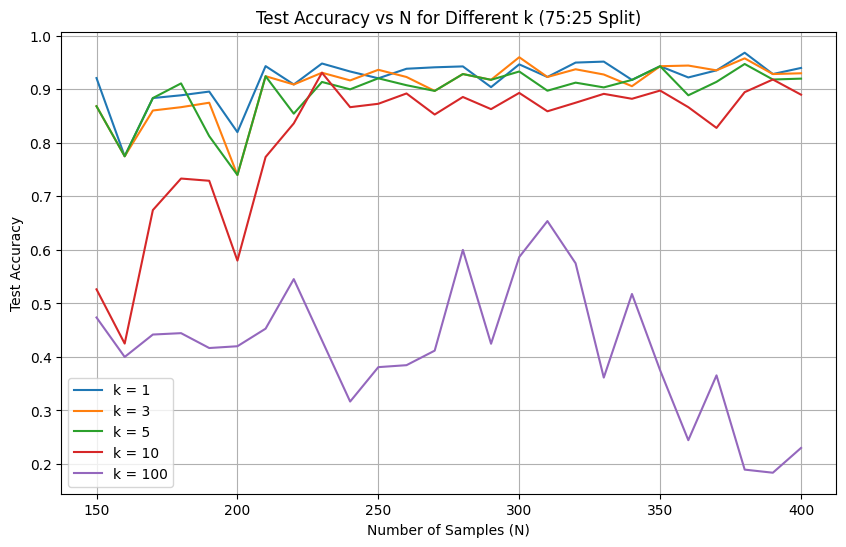

In [5]:
k_values = [1, 3, 5, 10, 100]

N_values = range(150, 401, 10)

plt.figure(figsize=(10,6))

for k in k_values:
    test_accuracies = []

    for N in N_values:
        X = np.linspace(0.0, 10.0, N)
        y = np.cos(2 * np.pi * X)

        y_class = (y > 0).astype(int)

        X = X.reshape(-1,1)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_class, test_size=0.25, random_state=42
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)

        test_accuracies.append(model.score(X_test, y_test))

    plt.plot(N_values, test_accuracies, label=f"k = {k}")

plt.xlabel("Number of Samples (N)")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs N for Different k (75:25 Split)")
plt.legend()
plt.grid()
plt.show()

with small N, large k is either invalid or leads to severe underfitting, while k=1 overfits due to high variance. As N increases, the model becomes more stable and moderate k values achieve higher and more consistent test accuracy, demonstrating that larger datasets reduce variance and improve generalization in KNN.